**Dataset:** dataset.csv

**Context:** Music Streaming Industry

This project aims to create **visual analytical support** for non-technical stakeholders in the music industry.
I used **Pandas** and **Matplotlib** to generate a range of clear and informative exploratory charts that illustrate key trends in the Spotify dataset.
The notebook emphasizes how effective data visualization helps decision-makers interpret complex data intuitively.

**Skills demonstrated:** Data visualization, exploratory analysis, Pandas, Matplotlib, stakeholder communication

**Questão 1 - Gráficos básicos com Matplotlib**

We Sing. We Dance. We Steal Things.
Love Is a Four Letter Word
Coffee Moment
Human - Best Adult Pop Tunes
Mellow Adult Pop
Holly Jolly Christmas
Feeling Good - Adult Pop Favorites
Christmas Time
Perfect Christmas Hits
Merry Christmas
Christmas Music - Holiday Hits
Know.
I Won't Give Up
Waiting for My Rocket to Come (Expanded Edition)
I'm Yours
YES!
Look For The Good
Waiting for My Rocket to Come
Have It All
Now That's What I Call Music 2012-13
Could I Love You Any More (feat. Jason Mraz)
Helpsters: Apple TV+ Original Series Soundtrack, Vol. 1


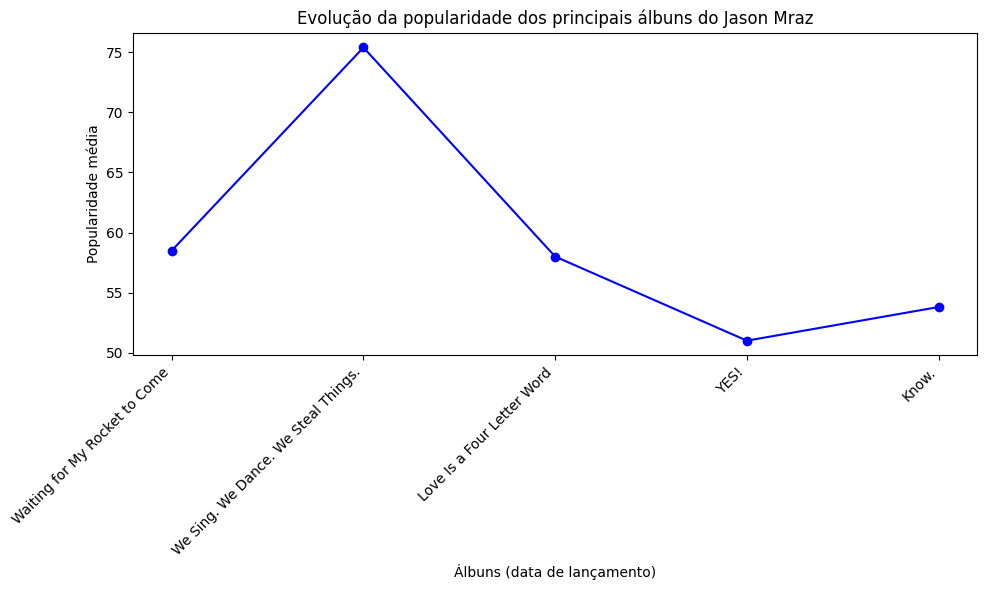

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df= pd.read_csv("dataset.csv")
jason_data= df[df['artists'].str.contains("Jason Mraz", case=False, na=False)]

unique_albums= jason_data['album_name'].unique()

for album in unique_albums:
    print(album)




jason_mraz_albums_ordered= [
"Waiting for My Rocket to Come",
"We Sing. We Dance. We Steal Things.",
"Love Is a Four Letter Word",
"YES!",
"Know."
]

df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

jason_data = df[df['album_name'].isin(jason_mraz_albums_ordered)]

popularity_by_album = jason_data.groupby('album_name')['popularity'].mean()

popularity_by_album= jason_data.groupby('album_name')['popularity'].mean()

popularity_by_album= popularity_by_album.reindex(jason_mraz_albums_ordered)

plt.figure(figsize=(10, 6))
plt.plot(popularity_by_album.index, popularity_by_album.values, marker='o', linestyle='-', color='b')
plt.title("Evolução da popularidade dos principais álbuns do Jason Mraz")
plt.xlabel("Álbuns (data de lançamento)")
plt.ylabel("Popularidade média")
plt.xticks(rotation=45, ha= 'right')

plt.tight_layout()

plt.show()




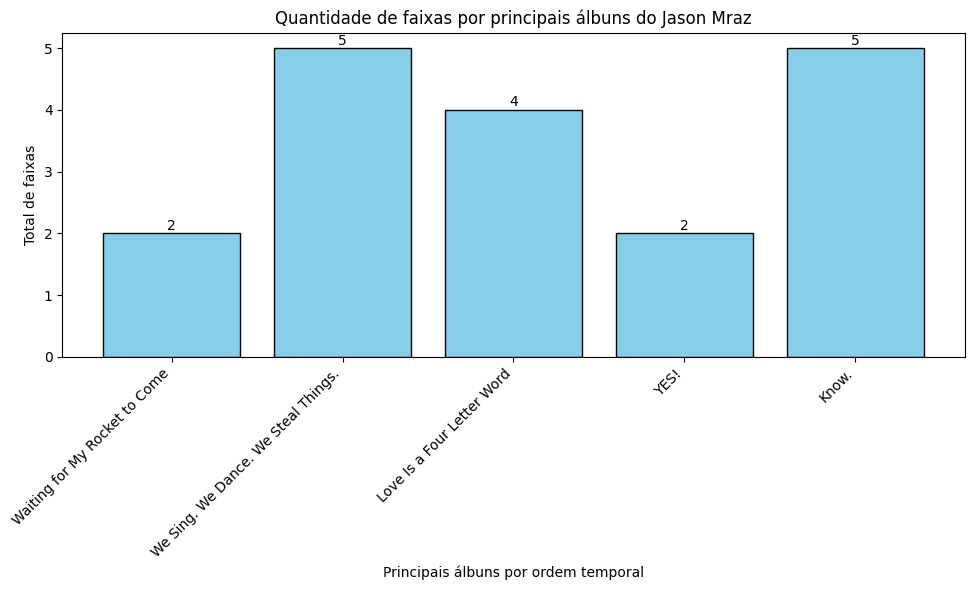

In [2]:
jason_mraz_albums_ordered= [
"Waiting for My Rocket to Come",
"We Sing. We Dance. We Steal Things.",
"Love Is a Four Letter Word",
"YES!",
"Know."
]
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')
jason_data = df[df['album_name'].isin(jason_mraz_albums_ordered)]
tracks_per_album= jason_data['album_name'].value_counts()
tracks_per_album= tracks_per_album.reindex(jason_mraz_albums_ordered)

plt.figure(figsize=(10,6))
plt.bar(tracks_per_album.index, tracks_per_album.values, color='skyblue', edgecolor='black')

plt.title("Quantidade de faixas por principais álbuns do Jason Mraz")
plt.xlabel("Principais álbuns por ordem temporal")
plt.ylabel("Total de faixas")
plt.xticks(rotation=45, ha= 'right')

for i, v in enumerate(tracks_per_album.values):
    plt.text(i, v + 0.01, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Gráfico de linha**
Proporciona um entendimento da própria carreira do cantor, quais álbuns que tiveram picos de popularidade e a presença de uma curva de crescimento/queda.

**Gráfico de barras**
Proporciona uma visão geral de quantas faixas existem em cada ábum principal do artista e se este número influencia ou não em sua popularidade (se cruzarmos as informações com o primeiro gráfico).

**Questão 2 - Estilo e subplots**

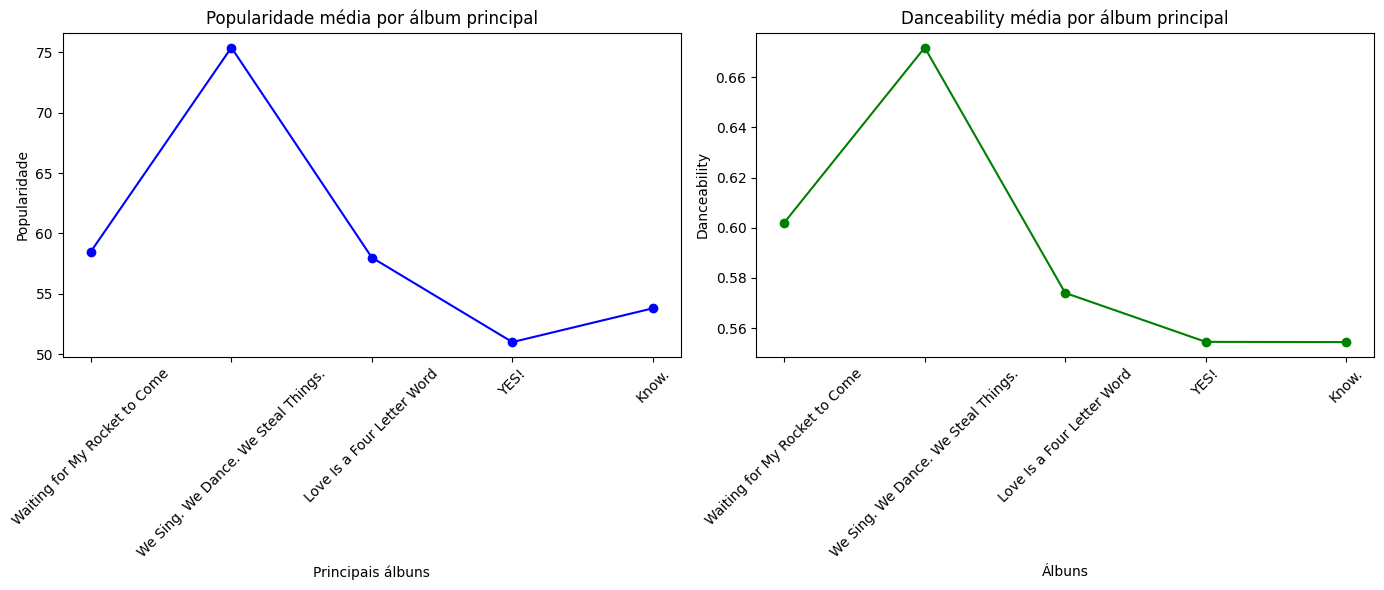

In [3]:
jason_mraz_albums_ordered= [
"Waiting for My Rocket to Come",
"We Sing. We Dance. We Steal Things.",
"Love Is a Four Letter Word",
"YES!",
"Know."
]

df['popularity']= pd.to_numeric(df['popularity'], errors='coerce')
df['danceability']= pd.to_numeric(df['danceability'], errors='coerce')

jason_data=df[df['album_name'].isin(jason_mraz_albums_ordered)]
metrics_by_album= jason_data.groupby('album_name')[['popularity', 'danceability']].mean()
metrics_by_album= metrics_by_album.reindex(jason_mraz_albums_ordered)

fig, axes= plt.subplots(1, 2, figsize=(14, 6), sharey= False)

axes[0].plot(metrics_by_album.index, metrics_by_album['popularity'], marker='o', linestyle='-', color='b')
axes[0].set_title("Popularidade média por álbum principal")
axes[0].set_xlabel("Principais álbuns")
axes[0].set_ylabel("Popularidade")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(metrics_by_album.index, metrics_by_album['danceability'], marker='o', linestyle='-', color='g')
axes[1].set_title("Danceability média por álbum principal")
axes[1].set_xlabel("Álbuns")
axes[1].set_ylabel("Danceability")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Na construção dos gráficos foram adotadas as seguintes escolhas estéticas:
- cores azul para a linha do primeiro gráfico e verde para a linha do segundo com o objetivo de diferenciá-los mais rapidamente;
- markers que ajudam a identificar os álbuns;
- ângulo de 45° no eixo x de forma a permitir a leitura clara dos títulos dos álbuns;
- "plt.tight_layout()" que permite o espaçamento entre os elementos dos gráficos, evitando que as informações se sobreponham.

Resumidamente, as escolhas estéticas são fundamentais na visualização dos gráficos, pois permitem uma leitura e um entendimento rápidos do problema. Quando pensamos em produto, em como devemos entregá-lo ao cliente, esta é uma característica que deve ser considerada. 


**Questão 3 - Distribuições e padrões**

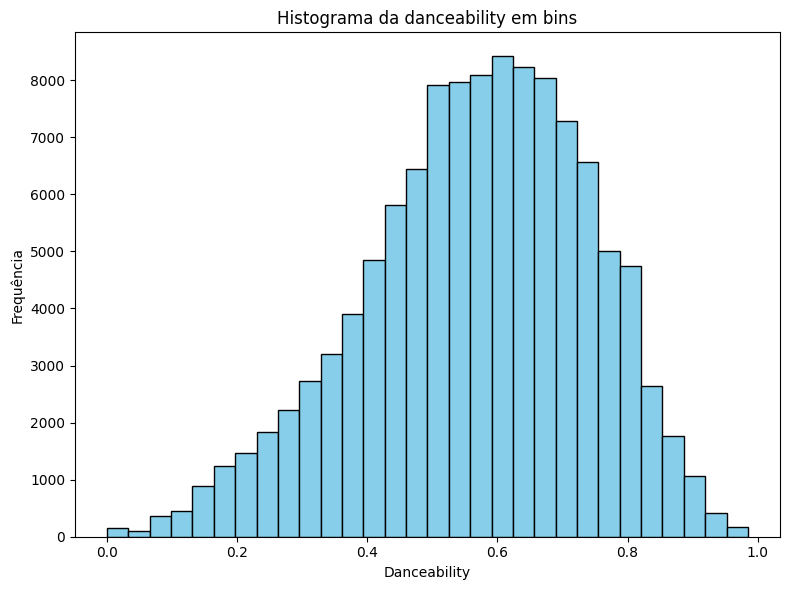

In [4]:
df['danceability']= pd.to_numeric(df['danceability'], errors='coerce')

plt.figure(figsize=(8, 6))
plt.hist(df['danceability'].dropna(), bins=30, color='skyblue', edgecolor='black')

plt.title("Histograma da danceability em bins")
plt.xlabel("Danceability")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

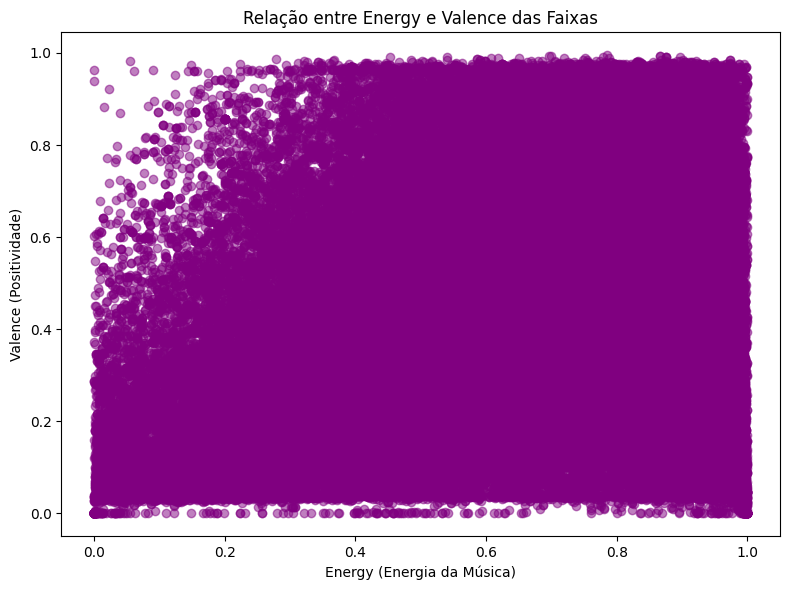

In [5]:
df['energy'] = pd.to_numeric(df['energy'], errors='coerce')
df['valence'] = pd.to_numeric(df['valence'], errors='coerce')

plt.figure(figsize=(8,6))
plt.scatter(df['energy'], df['valence'], alpha=0.5, color='purple')

plt.title("Relação entre Energy e Valence das Faixas")
plt.xlabel("Energy (Energia da Música)")
plt.ylabel("Valence (Positividade)")
plt.tight_layout()
plt.show()


**Histograma**
- Aqui podemos verificar uma frequência maior em termos de músicas mais dançantes entre 0.4 e 0.8. Podemos considerar outliers os poucos valores que representam os picos da danceability e os valores mais baixos. 

**Scatter plot**
- Neste gráfico os dados estão concentrados em sua maior parte entre 0.4 e 1.0 do eixo x, indicando uma compatibilidade alta entre a energia da música e sua positividade. 

**Questão 4 Proporções e dados angulares**

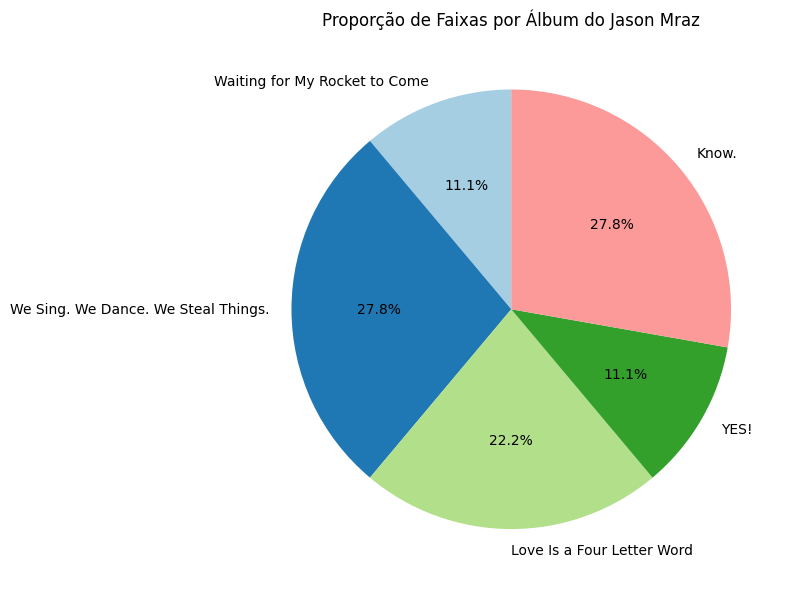

In [6]:
jason_mraz_albums_ordered= [
"Waiting for My Rocket to Come",
"We Sing. We Dance. We Steal Things.",
"Love Is a Four Letter Word",
"YES!",
"Know."
]

jason_data=df[df['album_name'].isin(jason_mraz_albums_ordered)]
tracks_per_album= jason_data['album_name'].value_counts()
tracks_per_album= tracks_per_album.reindex(jason_mraz_albums_ordered)
plt.figure(figsize=(8,8))
plt.pie(tracks_per_album.dropna(), labels=tracks_per_album.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

plt.title("Proporção de Faixas por Álbum do Jason Mraz")
plt.tight_layout()
plt.show()

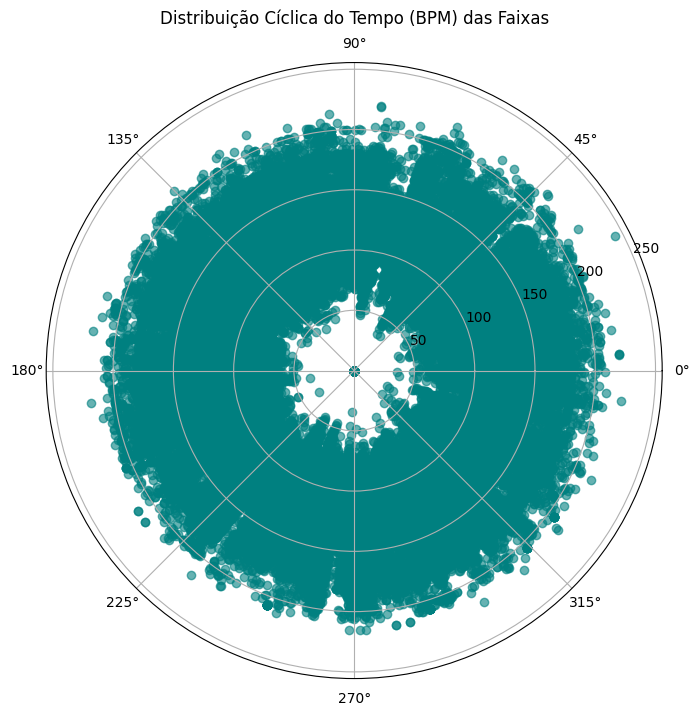

In [7]:
import numpy as np
df['tempo']= pd.to_numeric(df['tempo'], errors= 'coerce')
tempo_data=df['tempo'].dropna()
angles= np.linspace(0, 2*np.pi, len(tempo_data), endpoint=False)

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

ax.scatter(angles, tempo_data, alpha=0.6, c='teal')

ax.set_title("Distribuição Cíclica do Tempo (BPM) das Faixas", va='bottom')
plt.show()

**Grafico de pizza**
Vantagens - e uma boa opcao quando temos poucas categorias e queremos mostrar a diferenca percentual delas. A visualizacao acaba por ser mais intuitiva e mais clara. 
Desvantagens - torna-se confusa quando existem muitas categorias a serem mostradas. 

**Grafico polar**
Vantagens - ideal para representar categorias ciclicas como BPM, estacoes do ano e meses. Ajuda a identificar padroes circulares. 
Desvantagens - nao e tao intuitivo, podendo precisar de uma analise do seu funcionamento para posteriormente analisar os dados em si. 

**Questão 5 - Exploração com Pandas + Matplotlib**

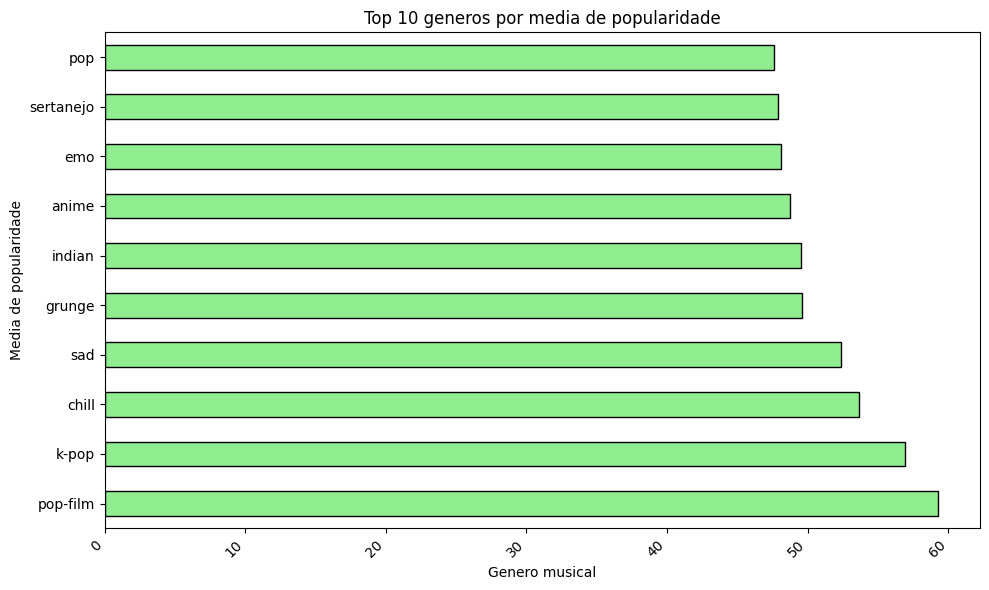

In [11]:
df['popularity']= pd.to_numeric(df['popularity'], errors= 'coerce')
popularity_by_genre= df.groupby("track_genre")['popularity'].mean()
popularity_by_genre= popularity_by_genre.sort_values(ascending=False).head(10)

popularity_by_genre.plot(
    kind='barh', 
    figsize=(10,6),
    color="lightgreen", 
    edgecolor="black", 
    title="Top 10 generos por media de popularidade"
)
plt.ylabel("Media de popularidade")
plt.xlabel("Genero musical")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


O Pandas e o Matplotlib funcionam bem em conjunto, pois um acaba por completar o outro na análise exploratória. Com o Pandas podemos preparar e agregar os dados através de funções prontas de agregação como sum(), mean() e value_counts() e com o Matplotlib podemos controlar a forma na qual os dados serão visualizados, criando figuras com diferentes cores, ângulos, formatos, legendas e tamanhos. Com o Matplotlib podemos criar gráficos mais detalhados e customizados, de forma rápida e eficiente. 

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5de8e3f5-0f25-4dba-a6d9-d0eb48da4eda' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>